RNN - Erro dos pesos computados e usado somente durante a iteração

In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm
import optuna
from optuna.exceptions import TrialPruned
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
#from Testing.RTLO import *
from Functions.RLS import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as rmse
FileName = ipynbname.name()

params = [12, 16, 12, 1e-06, 0.001, 1e-10, 0.0001, 1]

def prepare_data(sig, n, m):
    X, Y = [], []
    # O shift (s) é calculado para alinhar o final de Y com a predição futura
    # Seguindo sua lógica: se n=4, m=3 -> Y começa no índice 2 (hi_3)
    s = n - m + 1 
    
    for i in range(len(sig) - n - 1):
        X.append(sig[i : i + n])
        Y.append(sig[i + s : i + s + m])
        
    return np.array(X), np.array(Y)


In [ ]:
def f(x):
    return np.tanh(x)
def d_f(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow
def split_matrix(A):
    Ap = np.where(A > 0, A, 0)
    An = np.where(A < 0, A, 0)
    return An, Ap

def get_interval(A):
    v_max = np.max(A, axis=0)
    v_min = np.min(A, axis=0)
    
    return v_min, v_max

class RTLO:
    def __init__(self, nIN, nHS, nOUT,ηS=[0.1,0.1,0.1], τ=10,lr=1e-5):
        np.random.seed(42)
        self.nIN = nIN
        self.nHS = nHS
        self.nOUT = nOUT
        self.ΔOUT = np.zeros((nOUT, nHS))
        self.ΔHS = np.zeros((nHS, nHS))
        self.ΔIN = np.zeros((nHS, nIN))
        self.xI = np.zeros(nIN)
        self.ηS = np.array(ηS)
        self.τ = τ
        self.h0 = 0
        self.hI = np.zeros(nHS)
        self.hF = np.zeros(nHS)
        self.ht = np.zeros(nHS)
        self.htI = np.zeros((nHS,2))
        self.htL = np.zeros(nHS)
        self.htU = np.zeros(nHS)
        self.k = 0
        self.u = None
        self.decay = lr
        self.wIN = 0.1*(np.random.rand(nHS, nIN) - 1)
        self.wHS = 1.5*np.random.randn(nHS, nHS)/nHS**0.5
        self.wOUT = 0.1*(2*np.random.rand(nOUT, nHS) - 1)/nHS**0.5
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5
        self.p = np.zeros((self.nHS, self.nHS))
        self.q = np.zeros((self.nHS, self.nIN))
        self.wIN = self.xavier_uniform([nHS, nIN])
        self.wHS = self.xavier_uniform([nHS, nHS])
        self.wOUT = self.xavier_uniform([nOUT, nHS])
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5
        self.rls = RLS_LogarithmicRegressor(0.9,10000)
        self.yP = np.array([])
        self.yR = np.array([])
        self.yL = np.array([])
        self.yU = np.array([])
        self.eP = np.array([])
        self.eR = np.array([])
        self.eRMSE = np.array([])

    def fit(self, x, y, tip=1, store = False):
        self.ηS = self.ηS/(1 + self.decay*self.k)
        η1,η2,η3 = self.ηS
        self.u = np.dot(self.nHS,self.hI) + np.dot(self.wIN,x)
        self.hF = self.hI + (1/self.τ)*(-self.hI + f(self.u))
        yP = np.dot(self.wOUT, self.hF)
        e = y - yP
        self.p = np.outer(d_f(self.u),self.hI)/self.τ + (1-1/self.τ)*self.p
        self.q = np.outer(d_f(self.u),self.xI)/self.τ + (1-1/self.τ)*self.q
        δOUT = η1*np.outer(e,self.hF)
        δHS = η2*np.outer(np.dot(self.b, e),np.ones(self.nHS))*self.p
        δIN = η3*np.outer(np.dot(self.b, e),np.ones(self.nIN))*self.q

        self.ΔOUT = (self.ΔOUT*self.k/(self.k+1)) + (δOUT/(self.k+1))
        self.ΔHS = (self.ΔHS*self.k/(self.k+1)) + (δHS/(self.k+1))
        self.ΔIN =  (self.ΔIN*self.k/(self.k+1)) + (δIN/(self.k+1))

        self.wIN = self.wIN + self.ΔIN * tip
        self.wHS = self.wHS + self.ΔHS * tip
        self.wOUT = self.wOUT + self.ΔOUT * tip

        self.hI = self.hF
        self.ht = self.hF
        self.htL = self.hF
        self.htU = self.hF
        self.ht2 = self.hF
        self.xI = x

        self.k = self.k+1

        if store:
            self.yR = np.append(self.yR,y[-1])
            self.RMSE()

    def PredSingle(self,x,store=False):
        #print(self.ht)
        u = np.dot(self.wHS, self.ht) + np.dot(self.wIN, x)
        h = self.ht + (-self.ht + f(u))/self.τ
        y = np.dot(self.wOUT, h)
        self.ht = h

        if store:
            self.yP = np.append(self.yP,y[-1])
        return y
    
    import numpy as np


    def PredInterval_V1(self, x, e,store=False):
        x_interval = np.array(get_interval([x-e,x+e])).T

        self.htI = np.array(split_matrix(self.ht)).T
        #print(np.array([split_matrix(self.ht)]))

        wHS_p, wHS_n = np.maximum(0, self.wHS), np.minimum(0, self.wHS)
        wIN_p, wIN_n = np.maximum(0, self.wIN), np.minimum(0, self.wIN)
        wOUT_p, wOUT_n = np.maximum(0, self.wOUT), np.minimum(0, self.wOUT)

        u_hs_low = wHS_p @ self.htI[:, 0] + wHS_n @ self.htI[:, 1]
        u_hs_high = wHS_p @ self.htI[:, 1] + wHS_n @ self.htI[:, 0]
        
        u_in_low = wIN_p @ x_interval[:, 0] + wIN_n @ x_interval[:, 1]
        u_in_high = wIN_p @ x_interval[:, 1] + wIN_n @ x_interval[:, 0]
        
        u_low = u_hs_low + u_in_low
        u_high = u_hs_high + u_in_high
        u_int = np.column_stack((u_low, u_high))

        h_target = f(u_int) # Returns (hidden_dim, 2)

        diff_low = h_target[:, 0] - self.htI[:, 1]
        diff_high = h_target[:, 1] - self.htI[:, 0]
        
        h_low = self.htI[:, 0] + diff_low / self.τ
        h_high = self.htI[:, 1] + diff_high / self.τ
        
        y_low = wOUT_p @ h_low + wOUT_n @ h_high
        y_high = wOUT_p @ h_high + wOUT_n @ h_low
        yL = y_low[-1]
        yU = y_high[-1]
        if store:
            self.yL = np.append(self.yL,yL)
            self.yU = np.append(self.yU,yU)
        #self.htI = h_new
        return yL, yU
    
    def PredInterval_V2(self, x, e,store=False):
        xL,xU = x-e,x+e
        τ = self.τ

        if self.k <= 1:
            htU, htL = np.maximum(0, self.ht), np.minimum(0, self.ht)
        else: 
            htU, htL = self.htU, self.htL
        #htU, htL = np.maximum(0, self.ht), np.minimum(0, self.ht)
        wHS_p, wHS_n = np.maximum(0, self.wHS), np.minimum(0, self.wHS)
        wIN_p, wIN_n = np.maximum(0, self.wIN), np.minimum(0, self.wIN)
        wOUT_p, wOUT_n = np.maximum(0, self.wOUT), np.minimum(0, self.wOUT)


        uL = (wHS_p @ htL + wHS_n @ htU) + (wIN_p @ xL + wIN_n @ xU)
        uU = (wHS_p @ htU + wHS_n @ htL) + (wIN_p @ xU + wIN_n @ xL)
        
        htL_next = htL + (1/τ) * (-htL + np.tanh(uL))
        htU_next = htU + (1/τ) * (-htU + np.tanh(uU))

        self.htL, self.htU = htL_next, htU_next

        yL = wOUT_p @ htL_next + wOUT_n @ htU_next
        yU = wOUT_p @ htU_next + wOUT_n @ htL_next
        
        #print(yL)
        #print(yU)
        #print(htL)
        #print(htU)

        yL = yL[-1]
        yU = yU[-1]
        if store:
            self.yL = np.append(self.yL,yL)
            self.yU = np.append(self.yU,yU)
        #self.htI = h_new
        return yL, yU
    
    def restore(self):
        self.ht = self.hF
        self.ht2 = self.hF
        #self.htI = self.hF
    
    def xavier_uniform(self,shape):
        np.random.seed(42)
        n_in, n_out = shape
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=shape)
    
    def UpdateRLS_V1(self,y_p,y_r):
        eP = np.abs(self.rls.predict(np.abs(y_p[-1])))
        eR = np.abs(y_p-y_r)[-1]
        self.rls.update(np.abs(y_p[-1]), eR)
        self.eR = np.append(self.eR,eR)
        self.eP = np.append(self.eP,eP)
        return eP

    def UpdateRLS_V2(self,y_p,y_r):
        eR = np.abs(y_p-y_r)
        eP = np.zeros(len(y_r))
        for j,e in enumerate(eP):
            eP[j] = np.abs(self.rls.predict(np.abs(y_p[j])))
        for p,e in zip(y_p,eR):
            self.rls.update(np.abs(p), e)
        self.rls.update(np.abs(y_p[-1]), eR[-1])
        self.eR = np.append(self.eR,eR[-1])
        self.eP = np.append(self.eP,eP[-1])
        return eP
    
    def RMSE(self):
        RMSE = rmse(self.yR,self.yP)
        self.eRMSE = np.append(self.eRMSE, RMSE)
        return RMSE

    def PlotPred(self):
        plt.plot(self.yR,label='real')
        plt.plot(self.yP,label='pred')
        plt.legend()
        plt.show()

    def PlotPredError(self,w=9,h=3):
        
        t = np.arange(self.k)
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(w, h))
        axes = axes.flatten()
        ax1,ax2,ax3 = axes[0], axes[1], axes[2]

        ax1.plot(t, self.yR, color='black',label='Y-Real', linestyle='-')
        ax1.plot(t, self.yP, color='blue',label='Y-Pred', linestyle='-')
        ax1.plot(t, self.yL, color='black', linestyle='--')
        ax1.plot(t, self.yU, color='black', linestyle='--')
        ax1.set_title('Y - Real x Prediction')
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y', color='black')
        ax1.legend()

        ax2.plot(t, self.eR, color='black',label='e-Real', linestyle='-')
        ax2.plot(t, self.eP, color='blue',label='e-Pred', linestyle='-')
        ax2.set_title('Error - Real x Prediction')
        ax2.set_xlabel('X')
        ax2.set_ylabel('Prediction Error', color='black') 
        ax2.legend()
        
        ax3.plot(t, self.eRMSE, color='blue',label='RMSE', linestyle='-')
        ax3.set_title('RMSE')
        ax3.set_xlabel('X')
        ax3.set_ylabel('RMSE', color='black') 

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()


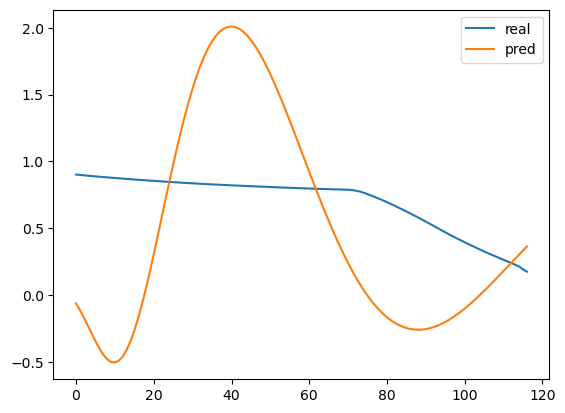

In [9]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
nIN,nOUT,nHS=5,3,3

sig = df['PC1'].values
X,Y = prepare_data(sig,n=nIN,m=nOUT)
xR,yR,yP = np.array([]),np.array([]),np.array([])
i=0

rtlo = RTLO(nIN,nHS,nOUT)
for x,y in zip(X,Y):
    
    y_p = rtlo.PredSingle(x,store=True)
    eP = rtlo.UpdateRLS_V1(y_p,y)
    rtlo.fit(x,y,store=True)
    yR = np.append(yR,y[-1])
    yP = np.append(yP,y_p[-1])
    xR = np.append(xR,i)
    i = i+1

rmse_rtlo = rmse(yR,yP)
rmse_rls = rmse(rtlo.eR,rtlo.eP)
 

rtlo.PlotPred()

In [8]:
yR,yP = np.array([]),np.array([])
xR = np.array([])
yV = []
xV=[]
i = 0
rtlo = RTLO(nIN,nHS,nOUT)
for x,y in zip(X,Y):
    y_p = rtlo.PredSingle(x)
    rtlo.restore()
    #y_v = rtlo.PredMulti(x,Thrs=0.2,stps=len(X))
    rtlo.restore()
    rtlo.fit(x,y)
    yR = np.append(yR,y[-1])
    yP = np.append(yP,y_p[-1])
    #yV.append(y_v)
    #x_v = np.arange(len(y_v)) + i
    #xV.append(x_v)
    xR = np.append(xR,i)
    i = i+1

In [ ]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
nIN,nOUT,nHS=5,7,3
sig = df['PC1'].values

X,Y = prepare_data(sig,n=nIN,m=nOUT)

print(' :',X[0])
print(' :',Y[0])

In [20]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def objective(trial):

    yR,yP = np.array([]),np.array([])
    nIN = trial.suggest_int('nIN', 2, 20) 
    nHS = trial.suggest_int('nHS', 1, 20) 
    nOUT = trial.suggest_int('nOUT', 1, 20) 
    N1 = trial.suggest_categorical('N1', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 
    N2 = trial.suggest_categorical('N2', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 
    N3 = trial.suggest_categorical('N3', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 
    lr = trial.suggest_categorical('lr', [1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1])
    τ = trial.suggest_int('τ', 1, 20)
    ηS = [N1,N2,N3]
    lb = trial.suggest_categorical('lb', [0.9,0.99,0.999,0.9999,0.99999])
    dt = trial.suggest_categorical('dt', [1,1e1,1e2,1e3,1e4,1e5])

    if nOUT > nIN:
        raise TrialPruned()
    X,Y = prepare_data(sig,n=nIN,m=nOUT)

    rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)
    rtlo.rls.lambda_ = lb
    rtlo.rls.delta = dt

    for i,_ in enumerate(X):
        x,y = X[i],Y[i]
        y_p = rtlo.PredSingle(x,store=True)
        eP = rtlo.UpdateRLS_V1(y_p,y)
        rtlo.fit(x,y,store=True)
        yR = np.append(yR,y[-1])
        yP = np.append(yP,y_p[-1])

    rmse_rtlo = rmse(yR,yP)
    rmse_rls = rmse(rtlo.eR,rtlo.eP)
    
    return rmse_rtlo*rmse_rls

sampler = optuna.samplers.TPESampler(multivariate=True,group=True)
study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    #pruner=pruner,
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db',
    #study_name=f'P{1}',
    load_if_exists=True)
study.optimize(objective, n_trials=1000)
best_params = study.best_params
params = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)

c:\Users\claud\anaconda3\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

c:\Users\claud\anaconda3\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning:

Argument ``group`` is an experimental feature. The interface can change in the future.

[I 2026-03-24 16:20:30,942] A new study created in memory with name: no-name-82c4a079-1c2c-47d9-bd24-b42a21080bbf
[I 2026-03-24 16:20:30,945] Trial 0 pruned. 
[I 2026-03-24 16:20:30,946] Trial 1 pruned. 
[I 2026-03-24 16:20:30,969] Trial 2 finished with value: 0.029873680594293288 and parameters: {'nIN': 16, 'nHS': 12, 'nOUT': 4, 'N1': 1e-07, 'N2': 1e-09, 'N3': 1e-08, 'lr': 1e-08, 'τ': 1, 'lb': 0.999, 'dt': 1000.0}. Best is trial 2 with value: 0.029873680594293288.
[I 2026-03-24 16:20:30,989] Trial 3 finished with value: 0.3534883400400551 and parameters: {'nIN': 16, 'nHS': 15, 'nOUT': 15, 'N1': 1e-09, 'N2': 1e-07, 'N3': 0.

Erro: 0.0007965798409938255 parameters:  [13, 20, 8, 1e-06, 0.001, 1e-07, 0.0001, 1, 0.99, 10000.0]


Erro: 0.05108550427322905 parameters:  [12, 16, 12, 1e-06, 0.001, 1e-10, 0.0001, 1] \
Erro: 0.0007965798409938255 parameters:  [13, 20, 8, 1e-06, 0.001, 1e-07, 0.0001, 1, 0.99, 10000.0]


0.03878707362239411


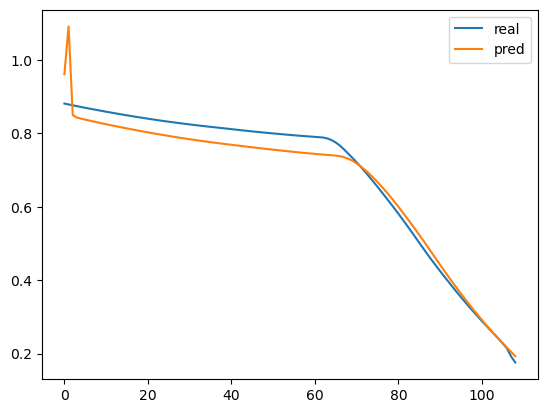

In [43]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
nIN,nHS,nOUT,N1,N2,N3,lr,τ,lb,dt =params
#nIN,nHS,nOUT = 4,4,4
ηS = [N1,N2,N3]
sig = df['PC1'].values
X,Y = prepare_data(sig,n=nIN,m=nOUT)
i=0

rtlo = rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)
for x,y in zip(X,Y):
    
    y_p = rtlo.PredSingle(x,store=True)
    eP = rtlo.UpdateRLS_V1(y_p,y)
    rtlo.fit(x,y,store=True)
    i = i+1

print(rmse(rtlo.yR,rtlo.yP))
rtlo.PlotPred()

In [35]:
vec = []


In [73]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
nIN,nHS,nOUT,N1,N2,N3,lr,τ,lb,dt =params
#nIN,nHS,nOUT = 4,4,4

ηS = [N1,N2,N3]
sig = df['PC1'].values
X,Y = prepare_data(sig,n=nIN,m=nOUT)
xR,yR,yP = np.array([]),np.array([]),np.array([])

rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)
yL,yU = np.array([]),np.array([])
xR = np.array([])
erroR = np.array([])
erroP = np.array([])

for i in range(len(X)):
#for i in range(2):

    y_r = Y[i]
    y_p = rtlo.PredSingle(X[i],store=True)

    eP = rtlo.UpdateRLS_V2(y_p,y_r)
    y_L, y_U = rtlo.PredInterval_V2(X[i],eP,store=True)
    rtlo.restore()
    rtlo.fit(X[i],Y[i],store=True)

rtlo.PlotPredError()
vec.append(rtlo.yL)

[0.91584566 0.91429178 0.91121962 0.90817817 0.90519636 0.90227154
 0.89941598 0.89663373 0.8939275  0.89128272 0.88870303 0.88617045
 0.88366572]
[0. 0. 0. 0. 0. 0. 0. 0.]


ValueError: operands could not be broadcast together with shapes (13,) (8,) 

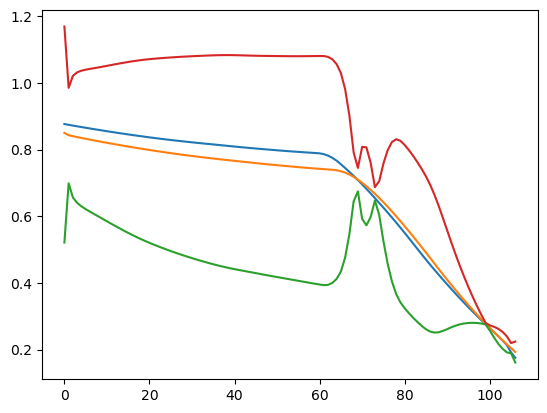

In [60]:
s=2
plt.plot(rtlo.yR[s:])
plt.plot(rtlo.yP[s:])
plt.plot(rtlo.yL[s:])
plt.plot(rtlo.yU[s:])

In [45]:
rtlo = RTLO(nIN,nHS,nOUT,ηS,τ,lr)

rtlo.htL

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])